# FedMedDx — Pneumonia Module Standalone Verification
**Owner:** Client 2 &nbsp;|&nbsp; **Task:** Binary classification — `NORMAL` vs `PNEUMONIA`
**Dataset:** [paultimothymooney/chest-xray-pneumonia](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
**Hardware:** Kaggle GPU T4 x2

This notebook trains and validates the `pneumonia_module.py` contract (from the FedMedDx repo) **standalone** —
It runs the exact same FedRep-style local training logic (Phase 1: head-only, Phase 2: full backbone)
on the real dataset, so you can validate accuracy and produce checkpoints/artifacts before the live federated run.

## 1. Environment & Reproducibility

In [1]:
import os, glob, json, time, copy, random, sqlite3, datetime
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

NUM_GPUS = torch.cuda.device_count()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA available: {torch.cuda.is_available()} | GPU count: {NUM_GPUS} | Device: {DEVICE}")
for i in range(NUM_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

if DEVICE == "cpu":
    print("WARNING: No GPU detected. Go to Settings -> Accelerator -> GPU T4 x2 and restart the session.")


CUDA available: True | GPU count: 2 | Device: cuda
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 2. Locate the Dataset 

In [2]:
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
NUM_CLASSES = 2

def find_dataset_root(search_root="/kaggle/input"):
    """Walk /kaggle/input to robustly locate every folder that directly contains
    both NORMAL/ and PNEUMONIA/ subfolders, regardless of nesting depth
    (the public dataset sometimes ships as chest_xray/chest_xray/train/... )."""
    candidates = set()
    for dirpath, dirnames, _ in os.walk(search_root):
        if "NORMAL" in dirnames and "PNEUMONIA" in dirnames:
            candidates.add(dirpath)
    if not candidates:
        raise FileNotFoundError(
            "Could not locate NORMAL/PNEUMONIA folders under /kaggle/input. "
            "Add the 'chest-xray-pneumonia' dataset via 'Add Input' on the right sidebar first."
        )
    return sorted(candidates)

split_dirs = find_dataset_root()
print(f"Found {len(split_dirs)} split director" + ("y" if len(split_dirs) == 1 else "ies") + ":")
for d in split_dirs:
    print(" -", d)


Found 9 split directories:
 - /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test
 - /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train
 - /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val
 - /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test
 - /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
 - /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val
 - /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test
 - /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
 - /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val


## 3. Gather Images, Deduplicate, and Build a Patient-Level Split

Two data-quality issues have to be handled before any split is trustworthy:

1. **Duplicate files.** This Kaggle dataset is sometimes mounted with a duplicated folder tree
   (e.g. `chest_xray/train/...` *and* `chest_xray/chest_xray/train/...` both present, with
   byte-identical images). If not deduplicated, the same physical image can land in both the
   training set and the validation/test set under two different paths — the model then partly
   "recognizes" images it was directly trained on, inflating every metric. We deduplicate by
   **MD5 content hash** so each physical image is counted exactly once, regardless of how many
   duplicate paths it's mounted under.
2. **Patient-level leakage.** Many PNEUMONIA filenames encode a shared patient ID, e.g.
   `person1946_bacteria_4874.jpeg` and `person1946_virus_3253.jpeg` are the same patient. A
   random image-level split can put one of that patient's images in train and another in val,
   letting the model partly learn patient-specific artifacts instead of the pathology. We group
   by patient ID and split at the **group** level with `GroupShuffleSplit` so a patient's images
   never span more than one split.

The original dataset's `val/` folder only has 16 images anyway (too small to trust for model
selection), so after cleaning we pool everything and carve out a fresh, group-aware
**70/15/15** train/val/test split.

In [3]:
import hashlib
import re

def file_md5(path, chunk_size=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

def gather_images(split_dirs):
    paths, labels, source_split = [], [], []
    for d in split_dirs:
        split_name = os.path.basename(d.rstrip("/"))
        for class_idx, class_name in enumerate(CLASS_NAMES):
            class_dir = os.path.join(d, class_name)
            files = (glob.glob(os.path.join(class_dir, "*.jpeg")) +
                     glob.glob(os.path.join(class_dir, "*.jpg")) +
                     glob.glob(os.path.join(class_dir, "*.png")))
            paths.extend(files)
            labels.extend([class_idx] * len(files))
            source_split.extend([split_name] * len(files))
    return np.array(paths), np.array(labels), np.array(source_split)

def deduplicate_by_content(paths, labels):
    """Keep only the first occurrence of each unique file (by MD5 hash of its bytes)."""
    seen_hashes = set()
    keep_paths, keep_labels = [], []
    for p, l in zip(paths, labels):
        h = file_md5(p)
        if h in seen_hashes:
            continue
        seen_hashes.add(h)
        keep_paths.append(p)
        keep_labels.append(l)
    return np.array(keep_paths), np.array(keep_labels)

def extract_patient_id(path, label):
    """PNEUMONIA files often share an ID like person1946_bacteria_4874.jpeg across several
    images of the same patient -> group them. NORMAL files don't expose a reliable shared-ID
    pattern in this dataset, so each is treated as its own group (no artificial grouping)."""
    fname = os.path.basename(path)
    match = re.match(r"person(\d+)_", fname)
    if match:
        return f"pneumonia_person{match.group(1)}"
    return f"single_{fname}"

raw_paths, raw_labels, raw_source = gather_images(split_dirs)
assert len(raw_paths) > 0, "No images found — check that the dataset was added correctly."
print(f"Raw file references found (before dedup): {len(raw_paths)}")
print(f"  By original Kaggle split directory: {pd.Series(raw_source).value_counts().to_dict()}")

all_paths, all_labels = deduplicate_by_content(raw_paths, raw_labels)
n_dupes = len(raw_paths) - len(all_paths)
print(f"\nDuplicate files removed: {n_dupes}")
print(f"Unique images after dedup: {len(all_paths)}")
print(f"  NORMAL:    {(all_labels == 0).sum()}")
print(f"  PNEUMONIA: {(all_labels == 1).sum()}")
if n_dupes == 0:
    print("  (No duplicates found in this mount — dataset was clean.)")


Raw file references found (before dedup): 11712
  By original Kaggle split directory: {'train': 10432, 'test': 1248, 'val': 32}

Duplicate files removed: 5888
Unique images after dedup: 5824
  NORMAL:    1579
  PNEUMONIA: 4245


In [6]:
from sklearn.model_selection import GroupShuffleSplit

patient_ids = np.array([extract_patient_id(p, l) for p, l in zip(all_paths, all_labels)])
n_groups = len(set(patient_ids))
print(f"Unique images: {len(all_paths)} | Unique patient groups: {n_groups}")

def group_split(paths, labels, groups, test_size, seed):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(gss.split(paths, labels, groups=groups))
    return idx_a, idx_b

# Step 1: carve out 15% test set, grouped by patient
idx_temp, idx_test = group_split(all_paths, all_labels, patient_ids, test_size=0.15, seed=SEED)

# Step 2: from the remaining 85%, carve out ~15% of the ORIGINAL total as val (~17.65% of remainder)
temp_paths, temp_labels, temp_groups = all_paths[idx_temp], all_labels[idx_temp], patient_ids[idx_temp]
idx_train_rel, idx_val_rel = group_split(temp_paths, temp_labels, temp_groups, test_size=0.1765, seed=SEED)

X_train, y_train = temp_paths[idx_train_rel], temp_labels[idx_train_rel]
X_val,   y_val   = temp_paths[idx_val_rel],   temp_labels[idx_val_rel]
X_test,  y_test  = all_paths[idx_test],       all_labels[idx_test]

# Sanity check: confirm no patient group appears in more than one split
train_groups = set(patient_ids[idx_temp][idx_train_rel])
val_groups   = set(patient_ids[idx_temp][idx_val_rel])
test_groups  = set(patient_ids[idx_test])
overlap = (train_groups & val_groups) | (train_groups & test_groups) | (val_groups & test_groups)
assert len(overlap) == 0, f"Patient group leakage detected: {overlap}"

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"  {name:5s} -> NORMAL: {(y==0).sum():4d}  PNEUMONIA: {(y==1).sum():4d}")
print("Patient-group leakage check passed: no group spans more than one split.")


Unique images: 5824 | Unique patient groups: 3253
Train: 4073 | Val: 880 | Test: 871
  Train -> NORMAL: 1131  PNEUMONIA: 2942
  Val   -> NORMAL:  230  PNEUMONIA:  650
  Test  -> NORMAL:  218  PNEUMONIA:  653
Patient-group leakage check passed: no group spans more than one split.


## 3c. Visual Sanity Check — What Does the Raw Data Actually Look Like?

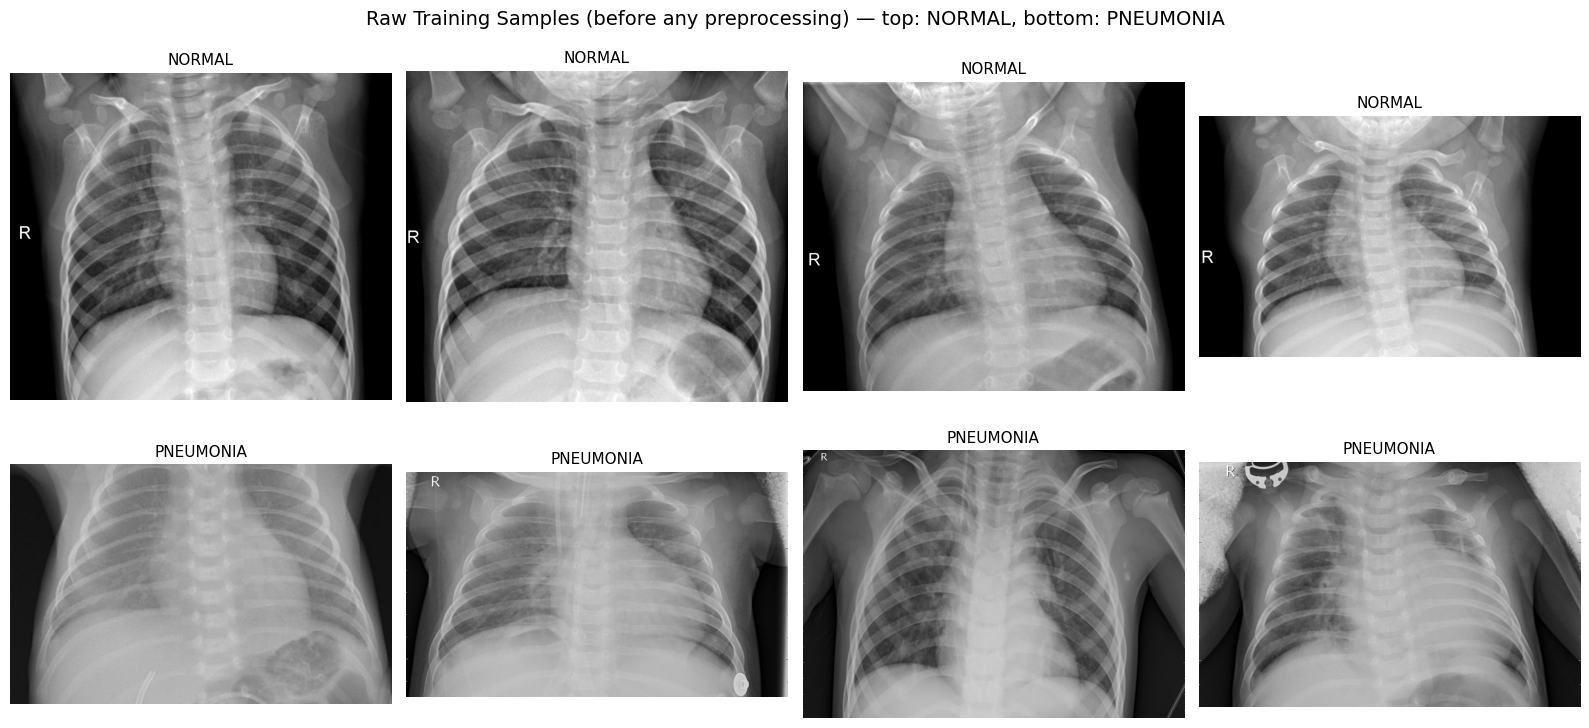

In [7]:
os.makedirs("/kaggle/working/results", exist_ok=True)

def show_sample_grid(paths, labels, class_names, n_per_class=4, title="Sample Images"):
    fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(4 * n_per_class, 4 * len(class_names)))
    for class_idx, class_name in enumerate(class_names):
        class_paths = paths[labels == class_idx]
        chosen = np.random.choice(class_paths, size=min(n_per_class, len(class_paths)), replace=False)
        for col, p in enumerate(chosen):
            img = Image.open(p).convert("RGB")
            ax = axes[class_idx, col]
            ax.imshow(img, cmap="gray")
            ax.set_title(class_name, fontsize=11)
            ax.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig("/kaggle/working/results/sample_images_raw.png", dpi=150)
    plt.show()

show_sample_grid(X_train, y_train, CLASS_NAMES, n_per_class=4,
                  title="Raw Training Samples (before any preprocessing) — top: NORMAL, bottom: PNEUMONIA")


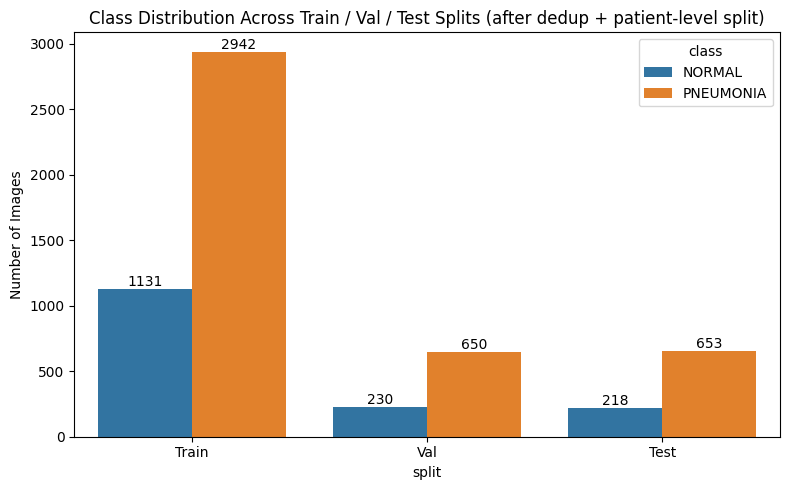

In [8]:
split_counts = pd.DataFrame({
    "split": ["Train"] * 2 + ["Val"] * 2 + ["Test"] * 2,
    "class": CLASS_NAMES * 3,
    "count": [
        (y_train == 0).sum(), (y_train == 1).sum(),
        (y_val == 0).sum(),   (y_val == 1).sum(),
        (y_test == 0).sum(),  (y_test == 1).sum(),
    ],
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=split_counts, x="split", y="count", hue="class", ax=ax)
ax.set_title("Class Distribution Across Train / Val / Test Splits (after dedup + patient-level split)")
ax.set_ylabel("Number of Images")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig("/kaggle/working/results/class_distribution.png", dpi=150)
plt.show()


## 4. Class Weights (Pneumonia is ~3:1 imbalanced)

In [9]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights [NORMAL, PNEUMONIA]:", class_weights)


Class weights [NORMAL, PNEUMONIA]: [1.80061892 0.69221618]


## 5. Dataset & Transforms (matches CONTRACT.md: RGB, 224x224, ImageNet normalization)

In [12]:
class CXRDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert("RGB")
        label = int(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label

def get_cxr_transforms(is_train: bool = True):
    if is_train:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

train_ds = CXRDataset(X_train, y_train, transform=get_cxr_transforms(True))
val_ds   = CXRDataset(X_val,   y_val,   transform=get_cxr_transforms(False))
test_ds  = CXRDataset(X_test,  y_test,  transform=get_cxr_transforms(False))

BATCH_SIZE = 32 * max(1, NUM_GPUS)   # scale batch size with GPU count (T4 x2 -> 64)
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Batch size: {BATCH_SIZE} | Train batches/epoch: {len(train_loader)}")


Batch size: 64 | Train batches/epoch: 64


## 5b. Visual Sanity Check — What Does the Model Actually See?

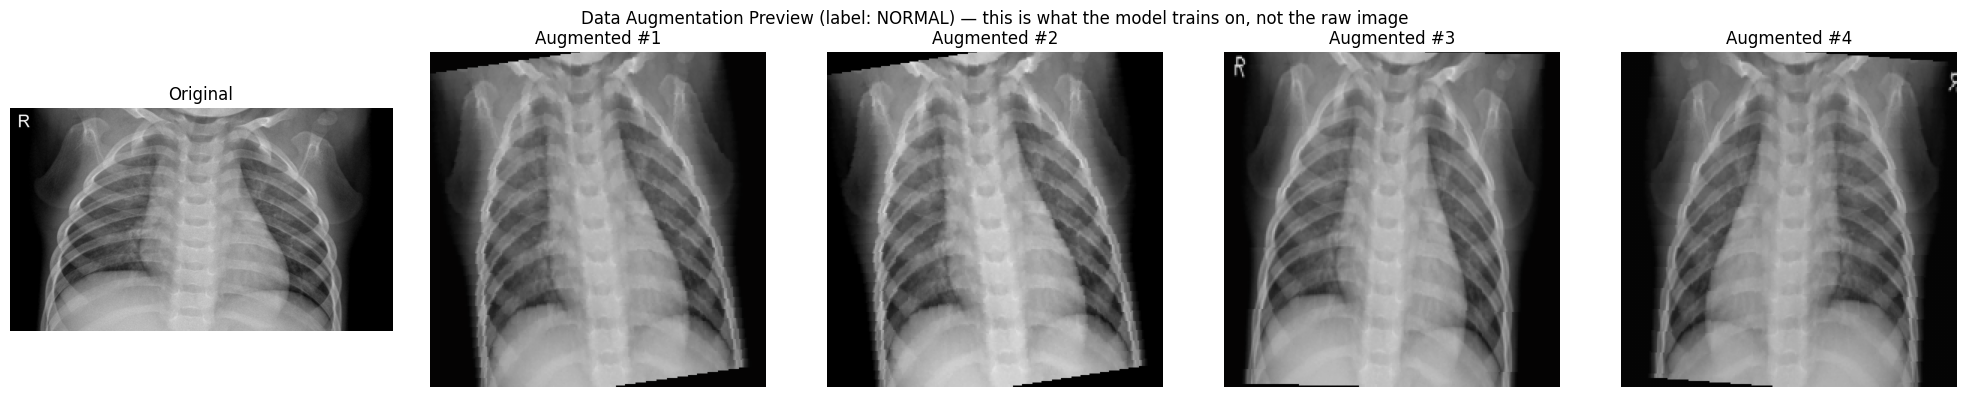

In [13]:
os.makedirs("/kaggle/working/results", exist_ok=True)

sample_path = X_train[0]
raw_img = Image.open(sample_path).convert("RGB")
train_transform = get_cxr_transforms(is_train=True)

def tensor_to_display(img_tensor):
    """Undo ImageNet normalization for display purposes only (model still sees the normalized version)."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(raw_img)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 5):
    augmented = train_transform(raw_img)
    axes[i].imshow(tensor_to_display(augmented))
    axes[i].set_title(f"Augmented #{i}")
    axes[i].axis("off")

plt.suptitle(f"Data Augmentation Preview (label: {CLASS_NAMES[y_train[0]]}) "
             f"— this is what the model trains on, not the raw image", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/results/augmentation_preview.png", dpi=150)
plt.show()


## 6. Model — `get_model()`

In [15]:
def get_model() -> nn.Module:
    """Returns ResNet18 configured with a 2-class binary classification head for Pneumonia.
    Recovers automatically from a corrupted/incomplete cached weights file by clearing the
    cache and retrying the download once."""
    try:
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    except (AttributeError, RuntimeError, EOFError) as e:
        cache_dir = os.path.join(torch.hub.get_dir(), "checkpoints")
        print(f"Pretrained weight load failed ({type(e).__name__}: {e}).")
        print(f"Clearing cached checkpoint(s) in {cache_dir} and retrying download...")
        if os.path.isdir(cache_dir):
            for fname in os.listdir(cache_dir):
                if "resnet18" in fname.lower():
                    removed_path = os.path.join(cache_dir, fname)
                    os.remove(removed_path)
                    print(f"  Removed corrupted file: {removed_path}")
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        print("Retry succeeded — pretrained weights loaded correctly.")
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model

base_model = get_model().to(DEVICE)

if NUM_GPUS > 1:
    model = nn.DataParallel(base_model)
    print(f"Wrapped model in nn.DataParallel across {NUM_GPUS} GPUs.")
else:
    model = base_model


Wrapped model in nn.DataParallel across 2 GPUs.


## 7. FedRep-Style Local Training 

In [28]:
def train_one_round(parallel_model: nn.Module, backbone_model: nn.Module, loader: DataLoader,
                     epochs: int, device: str, class_weights: torch.Tensor = None):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    total_loss, total_samples = 0.0, 0

    # Phase 1: Train Head (freeze backbone)
    for name, param in backbone_model.named_parameters():
        param.requires_grad = ("fc" in name)

    head_optimizer = torch.optim.Adam(backbone_model.fc.parameters(), lr=1e-3)
    parallel_model.train()
    for _ in range(max(1, epochs)):
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            head_optimizer.zero_grad()
            outputs = parallel_model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            head_optimizer.step()

    # Phase 2: Train full backbone (unfreeze everything)
    for param in backbone_model.parameters():
        param.requires_grad = True

    backbone_optimizer = torch.optim.Adam(backbone_model.parameters(), lr=1e-4)
    for _ in range(max(1, epochs)):
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            backbone_optimizer.zero_grad()
            outputs = parallel_model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            backbone_optimizer.step()
            total_loss += loss.item() * len(targets)
            total_samples += len(targets)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    avg_loss = total_loss / max(1, total_samples)
    return backbone_model.state_dict(), total_samples, avg_loss


## 8. Evaluation — accuracy, macro-F1, ROC-AUC

In [31]:
def evaluate(parallel_model: nn.Module, loader: DataLoader, device: str):
    parallel_model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, total = 0.0, 0
    all_preds, all_targets, all_probs = [], [], []

    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            outputs = parallel_model(images)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * len(targets)
            total += len(targets)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / max(1, total)
    acc = accuracy_score(all_targets, all_preds)
    f1_macro = f1_score(all_targets, all_preds, average="macro")
    try:
        auc = roc_auc_score(all_targets, all_probs)
    except ValueError:
        auc = 0.0

    metrics = {"accuracy": acc, "f1_macro": f1_macro, "auc_ovr": auc}
    return avg_loss, metrics, np.array(all_targets), np.array(all_preds), np.array(all_probs)


## 9. Training Loop

In [32]:
ROUNDS = 10
EPOCHS_PER_ROUND = 1
HOSPITAL_ID = 1  # Gargee = Client 2 -> hospital_id 1 (matches federated/client.py conventions)

os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/results", exist_ok=True)

history = []
best_val_auc = -1.0
best_state = None

print("--- Starting Standalone FedRep Verification Training (Gargee / Pneumonia) ---")
for r in range(1, ROUNDS + 1):
    t0 = time.time()
    _, n_samples, train_loss = train_one_round(
        model, base_model, train_loader, EPOCHS_PER_ROUND, DEVICE, class_weights_tensor
    )
    val_loss, val_metrics, _, _, _ = evaluate(model, val_loader, DEVICE)
    dt = time.time() - t0

    print(f"[Round {r:02d}/{ROUNDS}] "
          f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_acc={val_metrics['accuracy']*100:.2f}% | "
          f"val_f1={val_metrics['f1_macro']:.4f} | "
          f"val_auc={val_metrics['auc_ovr']:.4f} | {dt:.1f}s")

    history.append({
        "round": r, "train_loss": train_loss, "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"], "val_f1_macro": val_metrics["f1_macro"],
        "val_auc_ovr": val_metrics["auc_ovr"],
    })

    if val_metrics["auc_ovr"] > best_val_auc:
        best_val_auc = val_metrics["auc_ovr"]
        best_state = copy.deepcopy(base_model.state_dict())
        torch.save(best_state, "/kaggle/working/checkpoints/pneumonia_best_model.pth")
        torch.save(base_model.fc.state_dict(), f"/kaggle/working/checkpoints/client_pneumonia_{HOSPITAL_ID}_head.pth")
        print(f"  -> New best model saved (val_auc={best_val_auc:.4f})")

history_df = pd.DataFrame(history)
history_df.to_csv("/kaggle/working/results/training_history.csv", index=False)
history_df


--- Starting Standalone FedRep Verification Training (Gargee / Pneumonia) ---
[Round 01/10] train_loss=0.1715 | val_loss=0.1292 | val_acc=94.55% | val_f1=0.9326 | val_auc=0.9937 | 81.3s
  -> New best model saved (val_auc=0.9937)
[Round 02/10] train_loss=0.1221 | val_loss=0.0895 | val_acc=96.93% | val_f1=0.9603 | val_auc=0.9916 | 80.9s
[Round 03/10] train_loss=0.1038 | val_loss=0.0765 | val_acc=97.16% | val_f1=0.9635 | val_auc=0.9952 | 80.7s
  -> New best model saved (val_auc=0.9952)
[Round 04/10] train_loss=0.0963 | val_loss=0.0945 | val_acc=96.70% | val_f1=0.9582 | val_auc=0.9948 | 80.9s
[Round 05/10] train_loss=0.0778 | val_loss=0.0800 | val_acc=97.39% | val_f1=0.9664 | val_auc=0.9950 | 81.1s
[Round 06/10] train_loss=0.0701 | val_loss=0.0608 | val_acc=97.84% | val_f1=0.9717 | val_auc=0.9966 | 80.7s
  -> New best model saved (val_auc=0.9966)
[Round 07/10] train_loss=0.0730 | val_loss=0.1072 | val_acc=96.59% | val_f1=0.9567 | val_auc=0.9958 | 80.8s
[Round 08/10] train_loss=0.0645 | val

,round,train_loss,val_loss,val_accuracy,val_f1_macro,val_auc_ovr
0,1,0.171535,0.129180,0.945455,0.932626,0.993652
1,2,0.122107,0.089526,0.969318,0.960323,0.991639
2,3,0.103750,0.076544,0.971591,0.963466,0.995164
3,4,0.096309,0.094509,0.967045,0.958190,0.994843
4,5,0.077836,0.080006,0.973864,0.966389,0.995023
5,6,0.070133,0.060804,0.978409,0.971678,0.996555
6,7,0.072995,0.107170,0.965909,0.956690,0.995793
7,8,0.064451,0.070274,0.979545,0.973874,0.996763
8,9,0.055585,0.062549,0.979545,0.973803,0.997779
9,10,0.049110,0.078048,0.971591,0.963763,0.995231


## 10. Final Held-Out Test Evaluation (best checkpoint)

In [33]:
base_model.load_state_dict(best_state)
test_loss, test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, DEVICE)

print("=== FINAL HELD-OUT TEST SET RESULTS (best checkpoint) ===")
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']*100:.2f}%")
print(f"F1-macro:  {test_metrics['f1_macro']:.4f}")
print(f"AUC (ROC): {test_metrics['auc_ovr']:.4f}")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

with open("/kaggle/working/results/test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)


=== FINAL HELD-OUT TEST SET RESULTS (best checkpoint) ===
Loss:      0.0773
Accuracy:  97.24%
F1-macro:  0.9641
AUC (ROC): 0.9976

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.98      0.95       218
   PNEUMONIA       0.99      0.97      0.98       653

    accuracy                           0.97       871
   macro avg       0.95      0.98      0.96       871
weighted avg       0.97      0.97      0.97       871



## 11. Confusion Matrix & Training Curves

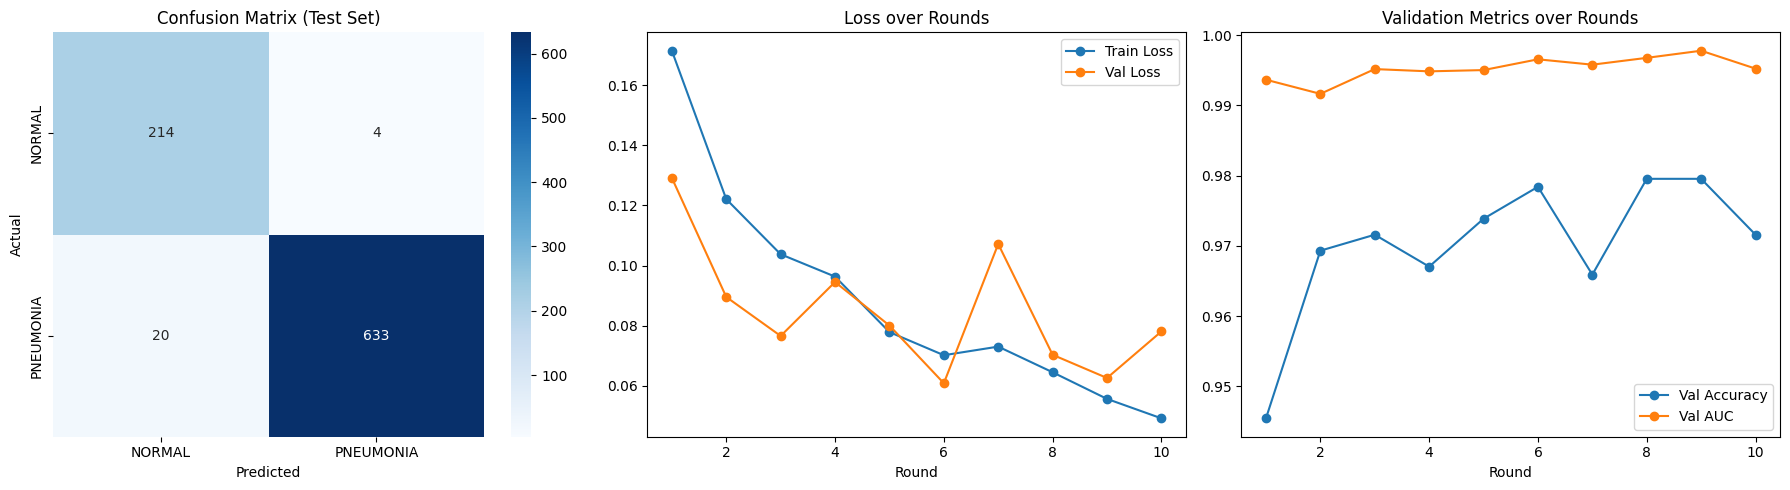

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (Test Set)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[1].plot(history_df["round"], history_df["train_loss"], label="Train Loss", marker="o")
axes[1].plot(history_df["round"], history_df["val_loss"], label="Val Loss", marker="o")
axes[1].set_title("Loss over Rounds")
axes[1].set_xlabel("Round")
axes[1].legend()

axes[2].plot(history_df["round"], history_df["val_accuracy"], label="Val Accuracy", marker="o")
axes[2].plot(history_df["round"], history_df["val_auc_ovr"], label="Val AUC", marker="o")
axes[2].set_title("Validation Metrics over Rounds")
axes[2].set_xlabel("Round")
axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/results/training_summary.png", dpi=150)
plt.show()


## 12. Grad-CAM Explainability
This is the answer to "how was pneumonia detected?" — Grad-CAM highlights which pixels the
trained model relied on to make each prediction (red/yellow = high influence).

In [36]:
class SimpleGradCAM:
    """Lightweight Grad-CAM using forward/backward hooks on the target layer (no external deps)."""
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        score = output[:, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def explain(model_for_cam: nn.Module, image: torch.Tensor, device: str):
    """Contract-compliant explain(): returns (predicted_class_idx, confidence, overlay_rgb_array)."""
    model_for_cam.to(device)
    model_for_cam.eval()
    input_tensor = image.unsqueeze(0).to(device) if image.dim() == 3 else image.to(device)

    with torch.no_grad():
        logits = model_for_cam(input_tensor)
        probs = torch.softmax(logits, dim=1)
        conf, pred = torch.max(probs, dim=1)

    cam_engine = SimpleGradCAM(model_for_cam, model_for_cam.layer4[-1])
    grayscale_cam, _ = cam_engine(input_tensor, class_idx=pred.item())

    rgb_img = input_tensor[0].permute(1, 2, 0).detach().cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-8)

    heatmap = plt.cm.jet(grayscale_cam)[:, :, :3]
    overlay = 0.5 * heatmap + 0.5 * rgb_img
    overlay = np.clip(overlay * 255, 0, 255).astype(np.uint8)

    return pred.item(), conf.item(), overlay


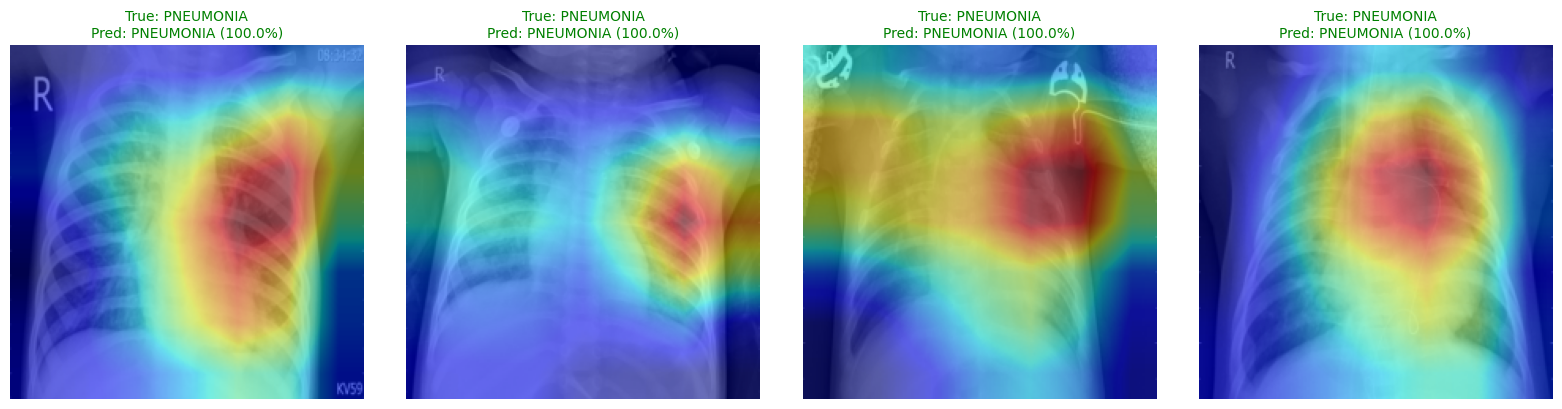

In [37]:
sample_idx = np.random.choice(len(test_ds), size=4, replace=False)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, idx in zip(axes, sample_idx):
    image, true_label = test_ds[idx]
    pred_idx, confidence, overlay = explain(base_model, image, DEVICE)
    ax.imshow(overlay)
    ax.set_title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_idx]} ({confidence*100:.1f}%)",
                 fontsize=10, color=("green" if pred_idx == true_label else "red"))
    ax.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/results/gradcam_samples.png", dpi=150)
plt.show()


## 13. Log Run to SQLite

In [38]:
DB_PATH = "/kaggle/working/results/fedmeddx_experiments.db"

def init_db(db_path=DB_PATH):
    os.makedirs(os.path.dirname(db_path), exist_ok=True)
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()
    cur.execute("""CREATE TABLE IF NOT EXISTS experiment_runs (
        run_id TEXT PRIMARY KEY, modality TEXT NOT NULL, strategy TEXT NOT NULL,
        alpha REAL NOT NULL, num_hospitals INTEGER NOT NULL, rounds INTEGER NOT NULL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP)""")
    cur.execute("""CREATE TABLE IF NOT EXISTS round_metrics (
        id INTEGER PRIMARY KEY AUTOINCREMENT, run_id TEXT NOT NULL, round_num INTEGER NOT NULL,
        hospital_id INTEGER NOT NULL, loss REAL NOT NULL, accuracy REAL NOT NULL,
        f1_macro REAL NOT NULL, auc_ovr REAL NOT NULL,
        FOREIGN KEY (run_id) REFERENCES experiment_runs (run_id))""")
    conn.commit()
    conn.close()

def log_run(modality, strategy, alpha, num_hospitals, rounds, db_path=DB_PATH):
    init_db(db_path)
    run_id = f"{modality}_{strategy}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    conn = sqlite3.connect(db_path)
    conn.execute("INSERT INTO experiment_runs (run_id, modality, strategy, alpha, num_hospitals, rounds) VALUES (?,?,?,?,?,?)",
                 (run_id, modality, strategy, alpha, num_hospitals, rounds))
    conn.commit()
    conn.close()
    return run_id

run_id = log_run("pneumonia", "FedRep-standalone", 0.5, 1, ROUNDS)
conn = sqlite3.connect(DB_PATH)
for row in history:
    conn.execute(
        "INSERT INTO round_metrics (run_id, round_num, hospital_id, loss, accuracy, f1_macro, auc_ovr) VALUES (?,?,?,?,?,?,?)",
        (run_id, row["round"], HOSPITAL_ID, row["val_loss"], row["val_accuracy"], row["val_f1_macro"], row["val_auc_ovr"])
    )
conn.commit()
conn.close()
print(f"Logged run '{run_id}' with {len(history)} rounds to {DB_PATH}")


Logged run 'pneumonia_FedRep-standalone_20260816_191255' with 10 rounds to /kaggle/working/results/fedmeddx_experiments.db


## 14. Summary

In [ ]:
print("GARGEE -- PNEUMONIA MODULE -- STANDALONE VERIFICATION SUMMARY")
print(f"Dataset images used : {len(all_paths)} (train={len(X_train)}, val={len(X_val)}, test={len(X_test)})")
print(f"GPUs used            : {NUM_GPUS}x {torch.cuda.get_device_name(0) if NUM_GPUS else 'CPU'}")
print(f"Rounds completed      : {ROUNDS}")
print(f"Best Val AUC          : {best_val_auc:.4f}")
print(f"Test Accuracy         : {test_metrics['accuracy']*100:.2f}%")
print(f"Test F1 (macro)       : {test_metrics['f1_macro']:.4f}")
print(f"Test AUC              : {test_metrics['auc_ovr']:.4f}")
print()
print("Saved artifacts (in /kaggle/working/):")
print("  checkpoints/pneumonia_best_model.pth        -> full ResNet18 state_dict (backbone+head)")
print(f"  checkpoints/client_pneumonia_{HOSPITAL_ID}_head.pth -> head only, matches client_wrapper.py naming")
print("  results/training_history.csv")
print("  results/test_metrics.json")
print("  results/training_summary.png")
print("  results/gradcam_samples.png")
print("  results/fedmeddx_experiments.db")


GARGEE -- PNEUMONIA MODULE -- STANDALONE VERIFICATION SUMMARY
Dataset images used : 5824 (train=4073, val=880, test=871)
GPUs used            : 2x Tesla T4
Rounds completed      : 10
Best Val AUC          : 0.9978
Test Accuracy         : 97.24%
Test F1 (macro)       : 0.9641
Test AUC              : 0.9976

Saved artifacts (in /kaggle/working/):
  checkpoints/pneumonia_best_model.pth        -> full ResNet18 state_dict (backbone+head)
  checkpoints/client_pneumonia_1_head.pth -> head only, matches client_wrapper.py naming
  results/training_history.csv
  results/test_metrics.json
  results/training_summary.png
  results/gradcam_samples.png
  results/fedmeddx_experiments.db
